# IC Walkthrough (Step by Step)

This notebook explains how the backtesting engine computes the Information Coefficient (IC) for one factor.

We use `alpha_101` as a concrete example and show the intermediate matrices and values created along the way.

In [1]:
from __future__ import annotations

import pandas as pd
import numpy as np

from quant_fund_agent.backtesting.data_loader import load_panel, forward_returns
from quant_fund_agent.factors import discover_factors, instantiate_factor

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

# Load your 50-ticker month of 10-second data
data = load_panel("ticker_data")

discover_factors()
factor = instantiate_factor("alpha_101")
print(f"Using factor: {factor.factor_id} | {factor.name}")
print("Fields loaded:", list(data.keys()))
print("Close shape:", data["close"].shape)

Using factor: alpha_101 | Alpha#101
Fields loaded: ['open', 'high', 'low', 'close', 'volume', 'spread', 'lobImb', 'depth']
Close shape: (46862, 50)


In [2]:
%load_ext autoreload
%autoreload 2

In [54]:
# 1) Compute factor signal and forward returns
horizon = 6  # 6 bars = 1 minute with 10-second data
signal = factor.calc(data)
fwd_ret = forward_returns(data["close"], horizon=horizon)

print("signal shape:", signal.shape)
print("fwd_ret shape:", fwd_ret.shape)

print("\nSignal (first 5 rows, first 5 tickers):")
display(signal.iloc[:5, :5])

print("\nForward returns (first 5 rows, first 5 tickers):")
display(fwd_ret.iloc[:5, :5])

signal shape: (46862, 50)
fwd_ret shape: (46862, 50)

Signal (first 5 rows, first 5 tickers):


,A,AAL,AAP,AAPL,ABBV
datetime,,,,,
2019-01-02 09:30:00,NaN,0.000000,0.993377,-0.993789,0.909091
2019-01-02 09:30:10,0.833333,0.000000,0.909091,0.833333,0.000000
2019-01-02 09:30:20,0.000000,0.952381,NaN,0.909091,0.995671
2019-01-02 09:30:30,0.000000,0.000000,NaN,0.952381,0.991736
2019-01-02 09:30:40,0.000000,0.000000,NaN,-0.909091,0.975610



Forward returns (first 5 rows, first 5 tickers):


,A,AAL,AAP,AAPL,ABBV
datetime,,,,,
2019-01-02 09:30:00,NaN,-0.002538,-0.001946,0.000355,0.002418
2019-01-02 09:30:10,0.000831,-0.001269,0.000000,0.002619,-0.000823
2019-01-02 09:30:20,NaN,-0.001744,NaN,0.003978,-0.002626
2019-01-02 09:30:30,-0.000829,-0.002380,NaN,0.005756,-0.003671
2019-01-02 09:30:40,NaN,-0.002859,NaN,0.003196,-0.003562


In [55]:
# 2) Align index/columns and build the valid mask
common_idx = signal.index.intersection(fwd_ret.index)
common_cols = signal.columns.intersection(fwd_ret.columns)

sig = signal.loc[common_idx, common_cols]
ret = fwd_ret.loc[common_idx, common_cols]

valid = sig.notna() & ret.notna()
n_valid = valid.sum(axis=1)

print("Aligned shape:", sig.shape)
print("\nValid mask (first 5 rows, first 5 tickers):")
display(valid.iloc[:5, :5])

print("\nNumber of valid assets per timestamp (head):")
display(n_valid.head(10))

Aligned shape: (46862, 50)

Valid mask (first 5 rows, first 5 tickers):


,A,AAL,AAP,AAPL,ABBV
datetime,,,,,
2019-01-02 09:30:00,False,True,True,True,True
2019-01-02 09:30:10,True,True,True,True,True
2019-01-02 09:30:20,False,True,False,True,True
2019-01-02 09:30:30,True,True,False,True,True
2019-01-02 09:30:40,False,True,False,True,True



Number of valid assets per timestamp (head):


datetime
2019-01-02 09:30:00    32
2019-01-02 09:30:10    34
2019-01-02 09:30:20    28
2019-01-02 09:30:30    32
2019-01-02 09:30:40    27
2019-01-02 09:30:50    29
2019-01-02 09:31:00    39
2019-01-02 09:31:10    34
2019-01-02 09:31:20    29
2019-01-02 09:31:30    36
dtype: int64

In [56]:
# 3) Cross-sectional ranks per timestamp (Spearman = Pearson on ranks)
sig_r = sig.rank(axis=1, na_option="keep").where(valid)
ret_r = ret.rank(axis=1, na_option="keep").where(valid)

print("Signal ranks (first 3 rows, first 8 tickers):")
display(sig_r.iloc[:3, :8])

print("\nReturn ranks (first 3 rows, first 8 tickers):")
display(ret_r.iloc[:3, :8])

# Pick one timestamp so you can inspect the full cross-section
t0 = sig_r.index[100]
print("\nExample timestamp:", t0)
example = pd.DataFrame({
    "signal": sig.loc[t0],
    "fwd_ret": ret.loc[t0],
    "signal_rank": sig_r.loc[t0],
    "ret_rank": ret_r.loc[t0],
}).dropna().sort_values("signal_rank")

display(example.head(15))

Signal ranks (first 3 rows, first 8 tickers):


,A,AAL,AAP,AAPL,ABBV,ABC,ABMD,ABT
datetime,,,,,,,,
2019-01-02 09:30:00,NaN,17.0,29.0,3.0,26.0,17.0,NaN,30.0
2019-01-02 09:30:10,26.5,16.0,30.0,29.0,16.0,16.0,NaN,37.0
2019-01-02 09:30:20,NaN,25.0,NaN,23.5,32.0,NaN,NaN,33.0



Return ranks (first 3 rows, first 8 tickers):


,A,AAL,AAP,AAPL,ABBV,ABC,ABMD,ABT
datetime,,,,,,,,
2019-01-02 09:30:00,NaN,5.0,6.0,16.0,26.0,23.0,NaN,11.0
2019-01-02 09:30:10,20.0,5.0,11.5,28.0,7.0,22.0,NaN,14.0
2019-01-02 09:30:20,NaN,6.0,NaN,27.0,2.0,NaN,NaN,14.0



Example timestamp: 2019-01-02 09:46:40


,signal,fwd_ret,signal_rank,ret_rank
ARE,-0.995671,0.001378,1.0,24.0
AMP,-0.990566,0.003457,2.0,38.0
APH,-0.982143,0.000313,3.0,13.0
AMT,-0.980392,0.000354,4.0,14.0
ALK,-0.980392,0.000505,5.0,15.0
ALL,-0.967742,0.000245,6.5,12.0
AIZ,-0.967742,-0.000338,6.5,4.0
AAP,-0.961538,0.000703,8.0,18.0
APA,-0.952381,0.000968,9.0,21.0
AMG,-0.937500,0.000569,10.0,17.0


In [57]:
# 4) Demean ranks row-wise and compute vectorized IC per timestamp
sig_mean = sig_r.mean(axis=1)
ret_mean = ret_r.mean(axis=1)

sig_dm = sig_r.sub(sig_mean, axis=0)
ret_dm = ret_r.sub(ret_mean, axis=0)

cov = (sig_dm * ret_dm).sum(axis=1)
sig_std = (sig_dm ** 2).sum(axis=1).pow(0.5)
ret_std = (ret_dm ** 2).sum(axis=1).pow(0.5)

denom = sig_std * ret_std
ic_series = (cov / denom.replace(0, np.nan))
ic_series = ic_series[n_valid >= 5].dropna()
ic_series.name = "IC"

print("IC series head:")
display(ic_series.head(10))

print("\nCheck one timestamp manually:")
print("cov[t0]     =", cov.loc[t0])
print("sig_std[t0] =", sig_std.loc[t0])
print("ret_std[t0] =", ret_std.loc[t0])
print("IC[t0]      =", ic_series.loc[t0])

IC series head:


datetime
2019-01-02 09:30:00   -0.286757
2019-01-02 09:30:10   -0.280962
2019-01-02 09:30:20    0.009971
2019-01-02 09:30:30   -0.058433
2019-01-02 09:30:40    0.053047
2019-01-02 09:30:50   -0.093127
2019-01-02 09:31:00   -0.068962
2019-01-02 09:31:10   -0.090326
2019-01-02 09:31:20   -0.241329
2019-01-02 09:31:30    0.023762
Name: IC, dtype: float64


Check one timestamp manually:
cov[t0]     = 216.99999999999994
sig_std[t0] = 87.64972903551956
ret_std[t0] = 72.97259759663213
IC[t0]      = 0.0339273039788452


In [58]:
# 5) Final metrics (same as engine)
ic_mean = float(ic_series.mean())
ic_std = float(ic_series.std())
ic_ir = float(ic_mean / ic_std) if ic_std > 0 else 0.0
ic_hit = float((ic_series > 0).mean())

print("Final metrics for", factor.factor_id)
print("information_coefficient:", round(ic_mean, 6))
print("ic_std:                ", round(ic_std, 6))
print("ic_ir:                 ", round(ic_ir, 6))
print("ic_hit_rate:           ", round(ic_hit, 4))
print("n_timestamps:          ", len(ic_series))

Final metrics for alpha_101
information_coefficient: -0.112445
ic_std:                 0.162528
ic_ir:                  -0.691849
ic_hit_rate:            0.2447
n_timestamps:           46849


In [61]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import json

In [19]:
data = pd.read_csv("binSamples/bin201901.csv")

In [12]:
fill_data = pd.read_csv("fillSamples/fills201901.csv")

In [22]:
tickers = data["stock"].unique()
for ticker in tickers:
    data_ticker = data[data["stock"] == ticker]
    os.makedirs(f"ticker_data/{ticker}", exist_ok=True)
    data_ticker.to_csv(f"ticker_data/{ticker}/bin201901.csv", index=False)
    

In [38]:
aapl = pd.read_csv("ticker_data/AAPL/bin201901.csv", parse_dates=["date"])

In [52]:
aapl.columns

Index(['date', 'time', 'stock', 'trade', 'orderFlow', 'hidden', 'auction',
       'mid', 'midEnd', 'spread', 'effSpread', 'lobImb', 'effLobImb', 'trdLiq',
       'ofLiq', 'depth', 'nbEvents', 'nbHidden', 'nbTrades'],
      dtype='str')

In [48]:
ob_data = pd.read_csv("AAPL_2025-10-01_2025-10-01_1/AAPL_2025-10-01_34200000_57600000_orderbook_1.csv")
ob_data.head(10)

,2551700,95,2549200,2
0,2551700,95,2549200,2
1,2551700,95,2549200,2
2,2551700,95,2549200,2
3,2551700,95,2549200,2
4,2551700,95,2549200,2
5,2551700,95,2549300,20
6,2551700,95,2549300,20
7,2551700,95,2549500,19
8,2551700,95,2549300,20
9,2551200,100,2549300,20


## Factor IC overview (full universe)

Cross-sectional Spearman IC vs forward returns is stored in `data/factors/factor_db.json` under each factor’s `backtest_metrics`. The default horizon in the DB is **6 bars** (~1 minute on 10s bars); horizons **1** and **60** are also available (`ic_by_horizon`).

The cells below load all factors, build **three** grouped bar charts and **three** heatmaps (one each for ranking on h=1, h=6, h=60), then summarise **whether the same factors stay on top** across horizons (Jaccard overlap, rank scatterplots, top‑k membership matrix).

Factors with IC at h=1,6,60: 86 / 88 loaded

Spearman correlation of |IC| across horizons:
         |IC|_1  |IC|_6  |IC|_60
|IC|_1    1.000   0.864    0.736
|IC|_6    0.864   1.000    0.845
|IC|_60   0.736   0.845    1.000

Overlap of top-N sets ranked by |IC| at each horizon — Jaccard index:
  N= 5  J(h1,h6)=1.00  J(h1,h60)=0.67  J(h6,h60)=0.67  |∩ all three|=4
  N=10  J(h1,h6)=1.00  J(h1,h60)=0.67  J(h6,h60)=0.67  |∩ all three|=8
  N=15  J(h1,h6)=0.76  J(h1,h60)=0.67  J(h6,h60)=0.67  |∩ all three|=12
  N=20  J(h1,h6)=0.74  J(h1,h60)=0.54  J(h6,h60)=0.67  |∩ all three|=14

Top-12 by |IC| — membership:
  In all three horizons: ['alpha_005', 'alpha_033', 'alpha_037', 'alpha_038', 'alpha_041', 'alpha_042', 'alpha_054', 'alpha_057', 'alpha_083', 'alpha_101']
  Only in h=1 top-12: []
  Only in h=6 top-12: []
  Only in h=60 top-12: ['alpha_032', 'alpha_094']
Mean: 0.03983467441860466
Max: 0.234896
Mean: 0.023311988372093025
Max: 0.115748
Mean: 0.011417430232558139
Max: 0.039401


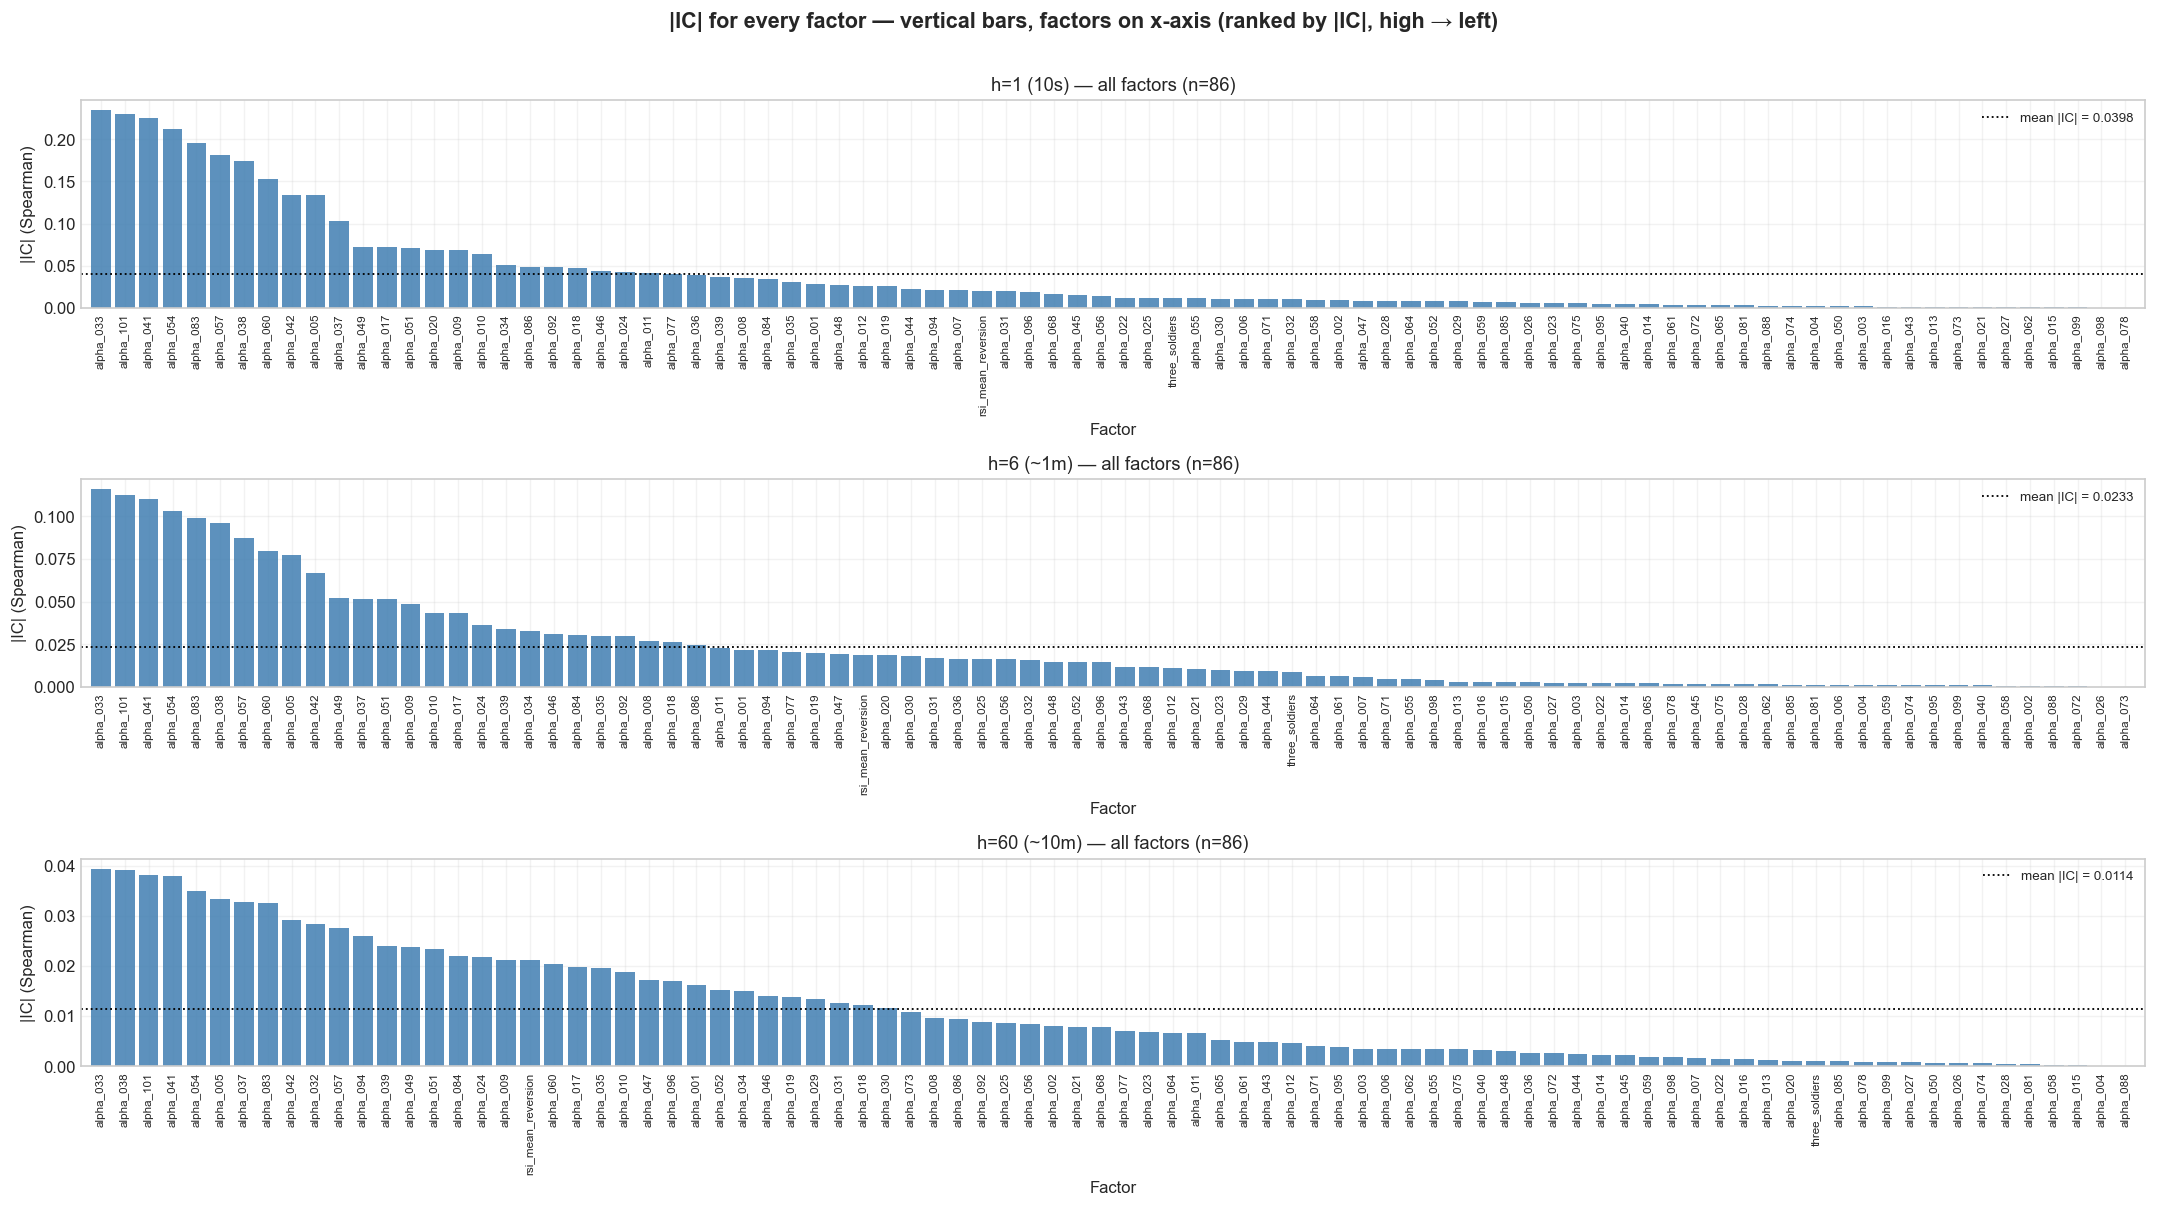

Bar chart panel sizes (factors with non-null IC): h=1→86, h=6→86, h=60→86


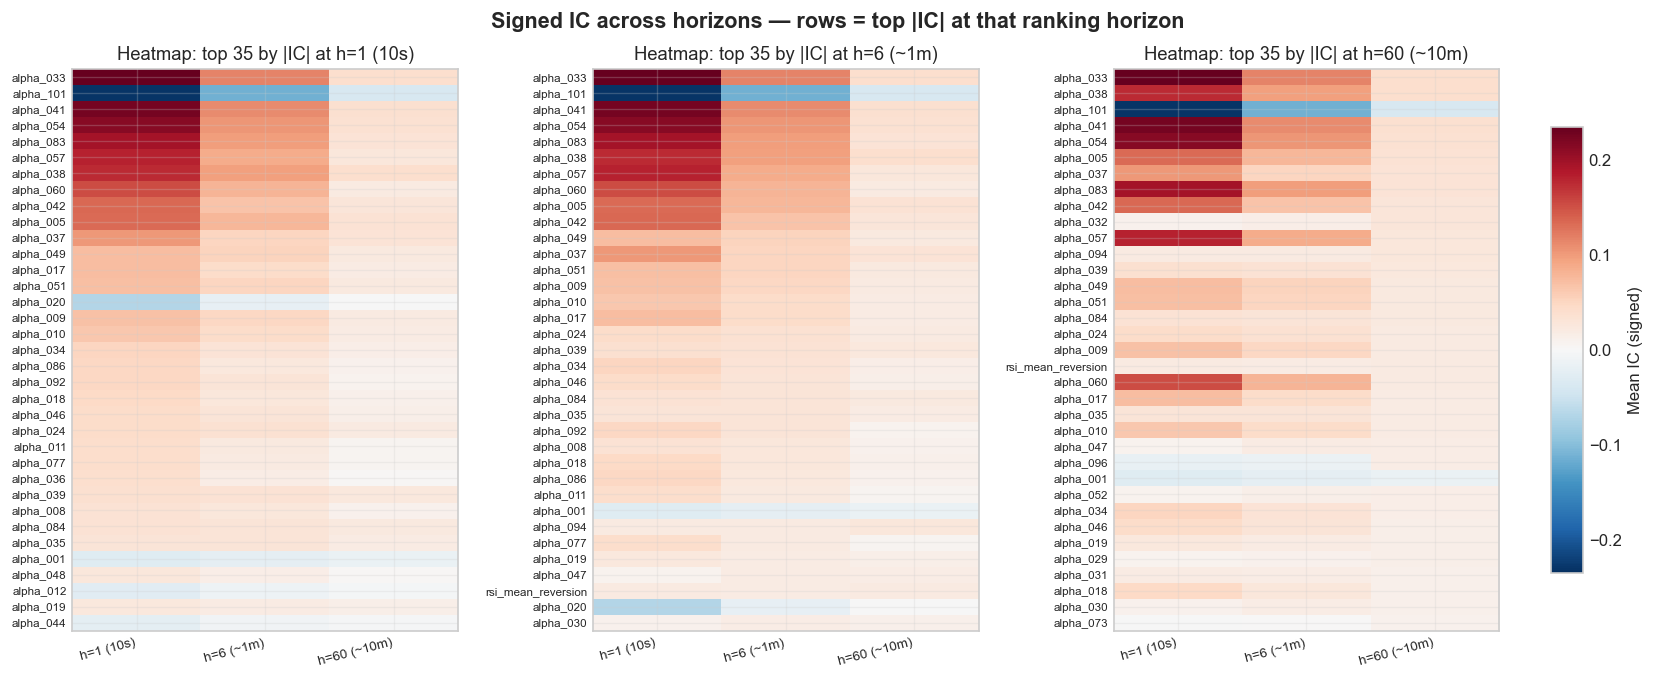

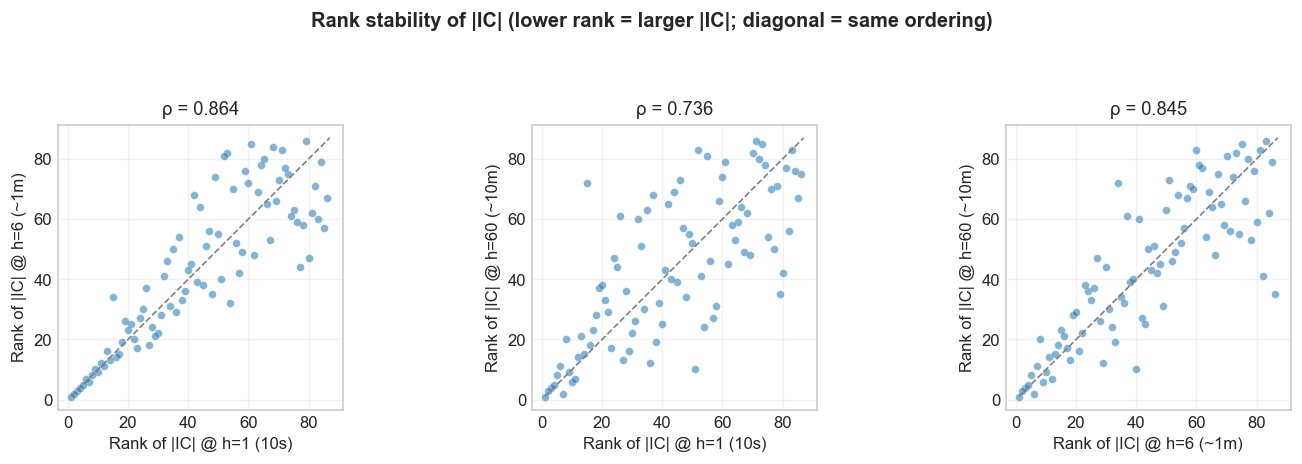

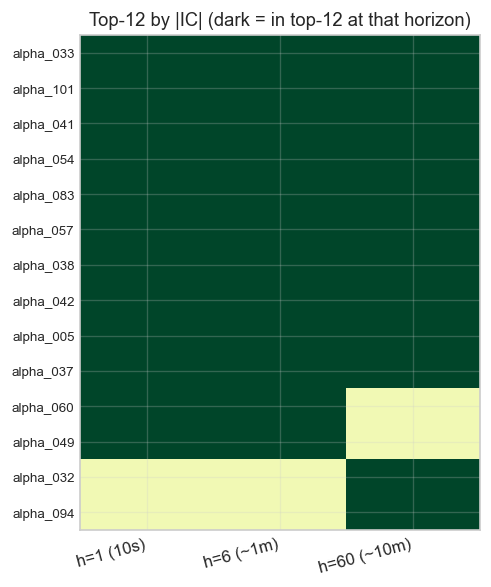

In [83]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path(".").resolve()
DB_PATH = ROOT / "data" / "factors" / "factor_db.json"

HORIZONS = ("1", "6", "60")
HORIZON_LABELS = {"1": "h=1 (10s)", "6": "h=6 (~1m)", "60": "h=60 (~10m)"}


def load_ic_dataframe(path: Path) -> pd.DataFrame:
    with path.open() as f:
        raw = json.load(f)
    rows: list[dict] = []
    for rec in raw["factors"]:
        m = rec.get("backtest_metrics")
        if not m:
            continue
        row: dict = {
            "id": rec["id"],
            "name": rec.get("name"),
            "ic_default": m.get("information_coefficient"),
            "icir_default": m.get("ic_ir"),
        }
        icbh = m.get("ic_by_horizon") or {}
        for h in HORIZONS:
            block = icbh.get(h) or {}
            row[f"ic_{h}"] = block.get("ic")
            row[f"icir_{h}"] = block.get("ic_ir")
        rows.append(row)
    df = pd.DataFrame(rows)
    df["alpha_idx"] = pd.to_numeric(
        df["id"].astype(str).str.replace("alpha_", "", regex=False),
        errors="coerce",
    )
    return df.sort_values("alpha_idx")


def plot_abs_ic_bar_all(df: pd.DataFrame, h: str, ax) -> int:
    """Vertical bars: every factor with a non-null IC at h, height = |IC| at h only."""
    col = f"ic_{h}"
    sub = df.dropna(subset=[col]).copy()
    a = sub[col].abs()
    sub = sub.assign(_abs=a).sort_values("_abs", ascending=False)
    x = np.arange(len(sub))
    ax.bar(x, sub["_abs"].values, width=0.82, color="steelblue", edgecolor="none", alpha=0.88)
    mean_abs = float(sub["_abs"].mean())
    max_abs = float(sub["_abs"].max())
    print(f"Mean: {mean_abs}")
    print(f"Max: {max_abs}")
    ax.axhline(mean_abs, color="black", linestyle=":", linewidth=1.1, label=f"mean |IC| = {mean_abs:.4f}")
    ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
    ax.set_xticks(x)
    fs = max(4, min(7, int(650 // max(len(sub), 1))))
    ax.set_xticklabels(sub["id"].tolist(), rotation=90, ha="center", fontsize=fs)
    ax.set_ylabel("|IC| (Spearman)")
    ax.set_xlabel("Factor")
    ax.set_title(f"{HORIZON_LABELS[h]} — all factors (n={len(sub)})")
    ax.margins(x=0.005)
    return len(sub)


def plot_ic_heatmap(df: pd.DataFrame, rank_h: str, m: int, ax, cbar_ax=None) -> None:
    """Rows: largest |IC| at rank_h; columns: signed IC at h=1,6,60."""
    col = f"ic_{rank_h}"
    base = df.dropna(subset=[col])
    idx = base[col].abs().nlargest(m).index
    subset = base.loc[idx].copy()
    subset = subset.assign(_mag=subset[col].abs()).sort_values("_mag", ascending=False).drop(
        columns="_mag"
    )
    mat = subset[[f"ic_{h}" for h in HORIZONS]].to_numpy()
    vmax = float(np.nanmax(np.abs(mat))) if mat.size else 0.15
    vmax = max(vmax, 1e-6)
    im = ax.imshow(mat, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(3))
    ax.set_xticklabels([HORIZON_LABELS[h] for h in HORIZONS], rotation=15, ha="right", fontsize=8)
    ax.set_yticks(range(len(subset)))
    ax.set_yticklabels(subset["id"].tolist(), fontsize=7)
    ax.set_title(f"Heatmap: top {m} by |IC| at {HORIZON_LABELS[rank_h]}")
    if cbar_ax is not None:
        plt.colorbar(im, cax=cbar_ax, label="Mean IC (signed)")
    return im


ic_df = load_ic_dataframe(DB_PATH)
ic_all = ic_df.dropna(subset=[f"ic_{h}" for h in HORIZONS]).copy()

print(f"Factors with IC at h=1,6,60: {len(ic_all)} / {len(ic_df)} loaded")

abs_block = ic_all[[f"ic_{h}" for h in HORIZONS]].abs()
abs_block.columns = [f"|IC|_{h}" for h in HORIZONS]
print("\nSpearman correlation of |IC| across horizons:")
print(abs_block.corr(method="spearman").round(3).to_string())


def top_k_ids(df: pd.DataFrame, h: str, k: int) -> set[str]:
    col = f"ic_{h}"
    sub = df.dropna(subset=[col])
    top_idx = sub[col].abs().nlargest(min(k, len(sub))).index
    return set(sub.loc[top_idx, "id"].tolist())


def jaccard(a: set[str], b: set[str]) -> float:
    if not a and not b:
        return 1.0
    u = len(a | b)
    return len(a & b) / u if u else 0.0


print("\nOverlap of top-N sets ranked by |IC| at each horizon — Jaccard index:")
for n in (5, 10, 15, 20):
    sets = {h: top_k_ids(ic_all, h, n) for h in HORIZONS}
    j_16 = jaccard(sets["1"], sets["6"])
    j_160 = jaccard(sets["1"], sets["60"])
    j_660 = jaccard(sets["6"], sets["60"])
    trip = sets["1"] & sets["6"] & sets["60"]
    print(f"  N={n:2d}  J(h1,h6)={j_16:.2f}  J(h1,h60)={j_160:.2f}  J(h6,h60)={j_660:.2f}  |∩ all three|={len(trip)}")

k_overlap = 12
sets_k = {h: top_k_ids(ic_all, h, k_overlap) for h in HORIZONS}
stable = sets_k["1"] & sets_k["6"] & sets_k["60"]
only_1 = sets_k["1"] - sets_k["6"] - sets_k["60"]
only_6 = sets_k["6"] - sets_k["1"] - sets_k["60"]
only_60 = sets_k["60"] - sets_k["1"] - sets_k["6"]
print(f"\nTop-{k_overlap} by |IC| — membership:")
print(f"  In all three horizons: {sorted(stable)}")
print(f"  Only in h=1 top-{k_overlap}: {sorted(only_1)}")
print(f"  Only in h=6 top-{k_overlap}: {sorted(only_6)}")
print(f"  Only in h=60 top-{k_overlap}: {sorted(only_60)}")

# Ranks by |IC| (1 = largest |IC|)
ranks = pd.DataFrame(
    {
        f"rank_{h}": ic_all[f"ic_{h}"].abs().rank(ascending=False, method="min").astype(int)
        for h in HORIZONS
    },
    index=ic_all.index,
)
ranks["id"] = ic_all["id"].values

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 150,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

M_HEAT = 35

# --- One figure: three panels, each = all factors, single |IC| bar for that horizon
ns = []
fig_bars, axes_bars = plt.subplots(3, 1, figsize=(18, 10))
fig_bars.suptitle(
    "|IC| for every factor — vertical bars, factors on x-axis (ranked by |IC|, high → left)",
    fontsize=13,
    fontweight="bold",
    y=1.002,
)
for ax, rh in zip(axes_bars, HORIZONS):
    ns.append(plot_abs_ic_bar_all(ic_df, rh, ax))
plt.tight_layout(rect=(0, 0, 1, 0.995))
plt.show()
print(f"Bar chart panel sizes (factors with non-null IC): h=1→{ns[0]}, h=6→{ns[1]}, h=60→{ns[2]}")

# --- Three heatmaps (|IC| defines row set and order)
fig_h, axes_h = plt.subplots(1, 3, figsize=(14.5, max(6, M_HEAT * 0.16)))
fig_h.suptitle(
    "Signed IC across horizons — rows = top |IC| at that ranking horizon",
    fontsize=13,
    fontweight="bold",
)
ims = []
for ax, rh in zip(axes_h, HORIZONS):
    plot_ic_heatmap(ic_df, rh, M_HEAT, ax)
    ims.append(ax.images[0])
vmin = min(im.get_array().min() for im in ims)
vmax = max(im.get_array().max() for im in ims)
vm = max(abs(vmin), abs(vmax), 1e-6)
for im in ims:
    im.set_clim(-vm, vm)
for ax in axes_h:
    if ax.images:
        ax.images[0].set_clim(-vm, vm)
fig_h.subplots_adjust(left=0.06, right=0.88, top=0.90, bottom=0.12, wspace=0.35)
cbar_ax = fig_h.add_axes([0.91, 0.2, 0.018, 0.62])
fig_h.colorbar(ims[0], cax=cbar_ax, label="Mean IC (signed)")
plt.show()

# --- Rank stability of |IC| across horizons
pairs = [("1", "6"), ("1", "60"), ("6", "60")]
fig_r, axes_r = plt.subplots(1, 3, figsize=(12, 3.8))
fig_r.suptitle(
    "Rank stability of |IC| (lower rank = larger |IC|; diagonal = same ordering)",
    fontsize=12,
    fontweight="bold",
)
for ax, (a, b) in zip(axes_r, pairs):
    ra = ranks[f"rank_{a}"]
    rb = ranks[f"rank_{b}"]
    ax.scatter(ra, rb, alpha=0.55, s=22, edgecolors="white", linewidths=0.25)
    lim = 1, len(ic_all) + 1
    ax.plot(lim, lim, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel(f"Rank of |IC| @ {HORIZON_LABELS[a]}")
    ax.set_ylabel(f"Rank of |IC| @ {HORIZON_LABELS[b]}")
    rho = ra.corr(rb, method="spearman")
    ax.set_title(f"ρ = {rho:.3f}")
    ax.set_aspect("equal", adjustable="box")
plt.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()

# --- Binary heatmap: top-k by |IC| at each horizon
union_top = sets_k["1"] | sets_k["6"] | sets_k["60"]
id_abs_max = ic_all.set_index("id")[[f"ic_{h}" for h in HORIZONS]].abs().max(axis=1)
ids_sorted = sorted(
    union_top,
    key=lambda fid: (
        -sum(fid in sets_k[h] for h in HORIZONS),
        -float(id_abs_max.loc[fid]),
    ),
)
mat_bin = np.zeros((len(ids_sorted), 3))
for i, fid in enumerate(ids_sorted):
    for j, h in enumerate(HORIZONS):
        mat_bin[i, j] = 1.0 if fid in sets_k[h] else 0.15

fig_m, ax_m = plt.subplots(figsize=(4.2, max(5, 0.32 * len(ids_sorted))))
ax_m.imshow(mat_bin, aspect="auto", cmap="YlGn", vmin=0, vmax=1)
ax_m.set_xticks(range(3))
ax_m.set_xticklabels([HORIZON_LABELS[h] for h in HORIZONS], rotation=15, ha="right")
ax_m.set_yticks(range(len(ids_sorted)))
ax_m.set_yticklabels(ids_sorted, fontsize=8)
ax_m.set_title(
    f"Top-{k_overlap} by |IC| (dark = in top-{k_overlap} at that horizon)"
)
plt.tight_layout()
plt.show()

In [74]:
with open('data/factors/factor_db.json', 'r') as f:
    raw_data = json.load(f)

# Print the keys or the first entry to see the nesting
factors = pd.DataFrame(raw_data["factors"])
factors["10s_ic"] = factors.apply(lambda x: x["backtest_metrics"]["ic_by_horizon"]["1"]["ic"], axis=1)
factors["1m_ic"] = factors.apply(lambda x: x["backtest_metrics"]["ic_by_horizon"]["6"]["ic"], axis=1)
factors["10m_ic"] = factors.apply(lambda x: x["backtest_metrics"]["ic_by_horizon"]["60"]["ic"], axis=1)
factors = factors[["id", "name", "class_name", "description", "10s_ic", "1m_ic", "10m_ic"]]
factors_ranked_10s = factors.sort_values("10s_ic", ascending=False)
factors_ranked_1m = factors.sort_values("1m_ic", ascending=False)
factors_ranked_10m = factors.sort_values("10m_ic", ascending=False)
factors_ranked_10s.head()
factors_ranked_1m.head()
factors_ranked_10m.head()

,id,name,class_name,description,10s_ic,1m_ic,10m_ic
32,alpha_033,Alpha#33,Alpha033,Cross-sectional rank of the intraday return (o...,0.234896,0.115748,0.039401
37,alpha_038,Alpha#38,Alpha038,Negative ranked 10-day time-series rank of clo...,0.174648,0.096142,0.039188
40,alpha_041,Alpha#41,Alpha041,Geometric midprice (sqrt(high*low)) minus VWAP...,0.225451,0.110220,0.037886
53,alpha_054,Alpha#54,Alpha054,Ratio of (close-low)*open^5 to (high-low)*clos...,0.212935,0.102810,0.035021
4,alpha_005,Alpha#5,Alpha005,Interaction between open-price deviation from ...,0.133388,0.077264,0.033424


In [84]:
from quant_fund_agent.backtesting.data_loader import load_panel
from quant_fund_agent.backtesting.strategy_backtester import backtest_strategy
from quant_fund_agent.factors import discover_factors, instantiate_factor
from quant_fund_agent.strategies import discover_strategies, instantiate_strategy

data = load_panel("ticker_data")

# discover registries
discover_factors()
discover_strategies()

# strategy
strategy = instantiate_strategy("alpha_blend_test")

# compute required factor signals
factor_signals = {}
for fid in strategy.factor_ids:
    f = instantiate_factor(fid)
    factor_signals[fid] = f.calc(data)

In [ ]:
res = backtest_strategy(strategy, factor_signals, data)

print(res.metrics)

annualised_return=0.058756 annualised_volatility=0.124285 sharpe_ratio=0.4728 sortino_ratio=0.5361 calmar_ratio=2.1745 max_drawdown=-0.02702 max_drawdown_duration_bars=21132 hit_rate=0.5015 profit_factor=1.0021 avg_win=9.342e-05 avg_loss=-9.381e-05 avg_daily_turnover=565.0609 avg_positions_held=20.0 ic_mean=0.004463 ic_ir=0.026977 extra={'n_bars': 46862, 'bars_per_day': 2340}


In [ ]:
for key, val in res.metrics:
    if key == "extra":
        continue
    print(f"  {key:30s}  {val}")

  annualised_return               0.058756
  annualised_volatility           0.124285
  sharpe_ratio                    0.4728
  sortino_ratio                   0.5361
  calmar_ratio                    2.1745
  max_drawdown                    -0.02702
  max_drawdown_duration_bars      21132
  hit_rate                        0.5015
  profit_factor                   1.0021
  avg_win                         9.342e-05
  avg_loss                        -9.381e-05
  avg_daily_turnover              565.0609
  avg_positions_held              20.0
  ic_mean                         0.004463
  ic_ir                           0.026977


In [89]:
"""Run the Selector Agent standalone and print its output.

Usage::

    export OPENAI_API_KEY=sk-...
    python run_selector.py
"""

from __future__ import annotations

import json
import os

from dotenv import load_dotenv

load_dotenv()

if not os.getenv("OPENAI_API_KEY"):
    raise RuntimeError("Set OPENAI_API_KEY in .env or environment before running.")

from quant_fund_agent.agents.selector.graph import selector_graph

result = selector_graph.invoke({})

print("=" * 80)
print("HYPOTHESIS")
print("=" * 80)
print(result["hypothesis"])
print()
print("REASONING")
print("-" * 80)
print(result["reasoning"])
print()
print("SELECTED FACTORS")
print("-" * 80)
for fid in result["selected_factor_ids"]:
    matching = [f for f in result["factor_catalog"] if f.factor_id == fid]
    if matching:
        f = matching[0]
        print(f"  {f.factor_id:15s} | {f.category:25s} | ICIR(1m)={f.icir_6}")
    else:
        print(f"  {fid}")
print()
print("SELECTION RATIONALE")
print("-" * 80)
print(result["selection_rationale"])

HYPOTHESIS
Combine mean-reversion factors (e.g., alpha_005, alpha_041, alpha_057) with momentum factors (e.g., alpha_038, alpha_049) to identify stocks exhibiting both significant mean-reversion potential and recent momentum. Enter long positions when mean-reversion signals are strong, and short positions when momentum signals indicate a potential reversal.

REASONING
--------------------------------------------------------------------------------
This strategy leverages the concept of mean reversion by targeting stocks that have deviated from their fair value (captured by mean-reversion factors), while also considering momentum to enhance the entry points. The rationale is that stocks showing both strong momentum and mean-reversion characteristics are likely to experience a price correction; hence, entering trades in the direction of the anticipated correction while considering the prevailing trend can optimize returns. Utilizing both strategies capitalizes on behavioral biases, where

In [95]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(name)-12s  %(message)s",
    datefmt="%H:%M:%S",
)

if not os.getenv("OPENAI_API_KEY"):
    raise RuntimeError("Set OPENAI_API_KEY in .env or environment before running.")

from quant_fund_agent.agents.selector.graph import selector_graph
from quant_fund_agent.agents.architect.graph import architect_graph

selector_result = result

print(f"\nHypothesis: {selector_result['hypothesis']}")
print(f"Reasoning:  {selector_result['reasoning'][:200]}…")
print(f"Selected:   {selector_result['selected_factor_ids']}")


# ── Step 2: Architect Agent ───────────────────────────────────────────

print("\n" + "=" * 80)
print("STEP 2: ARCHITECT AGENT")
print("=" * 80)

architect_input = {
    "hypothesis": selector_result["hypothesis"],
    "selected_factor_ids": selector_result["selected_factor_ids"],
    "factor_catalog": selector_result["factor_catalog"],
}

architect_result = architect_graph.invoke(architect_input)

spec = architect_result["strategy_spec"]
metrics = architect_result["backtest_metrics"]

print(f"\nStrategy:       {spec.strategy_name}")
print(f"Weights:        {spec.weights}")
print(f"Holding period: {spec.holding_period} bars")
print(f"Max positions:  {spec.max_positions}")
print(f"Equal weight:   {spec.equal_weight}")
print(f"Min conviction: {spec.min_conviction}")
print(f"Reasoning:      {spec.reasoning[:200]}…")

print("\n" + "-" * 80)
print("BACKTEST RESULTS")
print("-" * 80)
for key, val in metrics.items():
    if key == "extra":
        continue
    print(f"  {key:30s}  {val}")



Hypothesis: Combine mean-reversion factors (e.g., alpha_005, alpha_041, alpha_057) with momentum factors (e.g., alpha_038, alpha_049) to identify stocks exhibiting both significant mean-reversion potential and recent momentum. Enter long positions when mean-reversion signals are strong, and short positions when momentum signals indicate a potential reversal.
Reasoning:  This strategy leverages the concept of mean reversion by targeting stocks that have deviated from their fair value (captured by mean-reversion factors), while also considering momentum to enhance the …
Selected:   ['alpha_005', 'alpha_041', 'alpha_057', 'alpha_038', 'alpha_049']

STEP 2: ARCHITECT AGENT


14:44:09  INFO      httpx         HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
14:44:09  INFO      architect     Loading data from ticker_data …
14:44:13  INFO      architect     Data loaded in 3.5s
14:44:13  INFO      architect     Computing factor signals for ['alpha_005', 'alpha_041', 'alpha_057', 'alpha_038', 'alpha_049'] …
14:45:10  INFO      architect     Running backtest …
14:45:11  INFO      architect     Backtest done in 0.7s



Strategy:       Mean-Reversion Momentum Blend
Weights:        {'alpha_005': 0.2, 'alpha_041': 0.3, 'alpha_057': 0.2, 'alpha_038': -0.1, 'alpha_049': -0.1}
Holding period: 60 bars
Max positions:  20
Equal weight:   True
Min conviction: 0.5
Reasoning:      The strategy combines mean-reversion and momentum factors to capitalize on stocks that exhibit both tendencies. Weights are assigned based on the IC and ICIR values, with stronger mean-reversion facto…

--------------------------------------------------------------------------------
BACKTEST RESULTS
--------------------------------------------------------------------------------
  annualised_return               0.299153
  annualised_volatility           0.085929
  sharpe_ratio                    3.4814
  sortino_ratio                   4.0417
  calmar_ratio                    19.7099
  max_drawdown                    -0.015178
  max_drawdown_duration_bars      8448
  hit_rate                        0.501
  profit_factor              

In [ ]:
from quant_fund_agent.backtesting.data_loader import load_panel
from quant_fund_agent.backtesting.strategy_backtester import backtest_strategy
from quant_fund_agent.factors import discover_factors, instantiate_factor
from quant_fund_agent.strategies import discover_strategies, instantiate_strategy

data = load_panel("ticker_data")

# discover registries
discover_factors()
discover_strategies()

# strategy
strategy = instantiate_strategy("alpha_blend_test")

# compute required factor signals
factor_signals = {}
for fid in strategy.factor_ids:
    f = instantiate_factor(fid)
    factor_signals[fid] = f.calc(data)
    

In [1]:
from quant_fund_agent.agents.selector.graph import selector_graph
from quant_fund_agent.agents.architect.graph import architect_graph

selector_result = selector_graph.invoke({})

architect_result = architect_graph.invoke({
    "hypothesis": selector_result["hypothesis"],
    "selected_factor_ids": selector_result["selected_factor_ids"],
    "factor_catalog": selector_result["factor_catalog"],
    "max_iterations": 5,  # optional
})

architect_result["trial_history"]
architect_result["decision"]

'approve'

In [2]:
architect_result["trial_history"]

[TrialRecord(iteration=1, spec=StrategySpec(strategy_name='Mean-Reversion Momentum', weights={'alpha_005': 1.0, 'alpha_018': 0.5, 'alpha_041': 1.5, 'alpha_009': -0.5, 'alpha_038': -1.0}, holding_period=60, max_positions=30, equal_weight=True, min_conviction=0.5, reasoning='The strategy leverages strong mean-reversion signals (alpha_005, alpha_041) after a recent momentum-driven price increase, while reversing the signals from momentum factors (alpha_009, alpha_038) to fade the trend when necessary. The weights reflect the relative strength of the IC and ICIR values, emphasizing mean-reversion factors that have shown higher predictive power (especially alpha_041). The holding period of 60 bars allows for capturing the mean-reversion effect effectively, and the minimum conviction of 0.5 ensures only strong signals are acted upon.'), metrics={'annualised_return': -0.012783, 'annualised_volatility': 0.076999, 'sharpe_ratio': -0.166, 'sortino_ratio': -0.2017, 'calmar_ratio': -0.6151, 'max_d

In [4]:
import time

In [5]:
MAX_ITERATIONS = 5
OOS_RATIO = 0.2
SKIP_STATISTICIAN = False   

import importlib
import sys
from pathlib import Path
sys.path.insert(0, str(Path("/Users/lucawurker/Desktop/Imperial/Master Thesis/QuantFundAgent").resolve()))

_selector_mod = importlib.import_module("quant_fund_agent.agents.selector.graph")
_architect_mod = importlib.import_module("quant_fund_agent.agents.architect.graph")
importlib.reload(_architect_mod)
_statistician_mod = importlib.import_module("quant_fund_agent.agents.statistician.graph")
importlib.reload(_statistician_mod)
importlib.reload(_selector_mod)

selector_graph = _selector_mod.selector_graph
architect_graph = _architect_mod.architect_graph
statistician_graph = _statistician_mod.statistician_graph

pipeline_t0 = time.perf_counter()

# ---------- STEP 1: SELECTOR ----------
print("\n" + "=" * 80)
print("STEP 1: SELECTOR AGENT  (start)")
print("=" * 80)
t0 = time.perf_counter()
selector_result = selector_graph.invoke({})
dt = time.perf_counter() - t0
print(f">>> Selector finished in {dt:.2f}s\n")

print(f"Hypothesis: {selector_result['hypothesis']}")
print(f"Reasoning:  {selector_result['reasoning'][:400]}")
print(f"Selected:   {selector_result['selected_factor_ids']}")

# ---------- STEP 2: ARCHITECT ----------
print("\n" + "=" * 80)
print(f"STEP 2: ARCHITECT AGENT  (max_iterations={MAX_ITERATIONS}, oos_ratio={OOS_RATIO})")
print("=" * 80)
architect_input = {
    "hypothesis": selector_result["hypothesis"],
    "selected_factor_ids": selector_result["selected_factor_ids"],
    "factor_catalog": selector_result["factor_catalog"],
    "max_iterations": MAX_ITERATIONS,
    "oos_split_ratio": OOS_RATIO,
}
t0 = time.perf_counter()
architect_result = architect_graph.invoke(architect_input)
print(f">>> Architect finished in {time.perf_counter() - t0:.2f}s\n")

print("-" * 80)
print(f"TRIAL HISTORY  (total trials: {len(architect_result['trial_history'])})")
print("-" * 80)
for trial in architect_result["trial_history"]:
    m = trial.metrics
    print(f"\n  Trial {trial.iteration}: {trial.spec.strategy_name}")
    print(f"    Sharpe: {m.get('sharpe_ratio')}  MaxDD: {m.get('max_drawdown')}")
    print(f"    Reasoning (snippet): {trial.spec.reasoning[:200]}...")

print("\n" + "-" * 80)
print(f"ARCHITECT FINAL DECISION: {architect_result['decision'].upper()}")
print("-" * 80)
print(architect_result["decision_reasoning"])

# ---------- STEP 3: STATISTICIAN (optional) ----------
if SKIP_STATISTICIAN:
    print("\n>>> Skipping statistician (SKIP_STATISTICIAN=True)")
elif architect_result["decision"] != "approve":
    print("\n>>> Statistician skipped: architect did not approve.")
else:
    print("\n" + "=" * 80)
    print("STEP 3: STATISTICIAN AGENT")
    print("=" * 80)
    statistician_input = {
        "hypothesis": architect_result["hypothesis"],
        "strategy_spec": architect_result["strategy_spec"],
        "trial_history": architect_result["trial_history"],
        "backtest_metrics": architect_result["backtest_metrics"],
        "initial_reasoning": architect_result.get("initial_reasoning", ""),
        "final_reasoning": architect_result["strategy_spec"].reasoning,
        "oos_split_ratio": OOS_RATIO,
    }
    t0 = time.perf_counter()
    stat_result = statistician_graph.invoke(statistician_input)
    print(f">>> Statistician finished in {time.perf_counter() - t0:.2f}s\n")

    print("-" * 80)
    print("STATISTICAL TESTS")
    print("-" * 80)
    for r in stat_result["test_results"]:
        print(f"\n  [{r.verdict.value.upper()}] {r.test_name}")
        print(f"    value={r.value}  threshold={r.threshold}  p={r.p_value}")
        print(f"    {r.summary}")

    print("\n" + "-" * 80)
    print("RISK ASSESSMENT")
    print("-" * 80)
    print(stat_result.get("risk_assessment", "(none)"))

    print("\n" + "-" * 80)
    print(f"STATISTICIAN FINAL DECISION: {stat_result['final_decision'].upper()}")
    print("-" * 80)
    print(stat_result["final_reasoning_statistician"])

print(f"\n>>> Total pipeline wall time: {time.perf_counter() - pipeline_t0:.2f}s")


STEP 1: SELECTOR AGENT  (start)
>>> Selector finished in 13.86s

Hypothesis: Combine mean-reversion factors like alpha_005 and alpha_041 with momentum factors such as alpha_009 and alpha_017 to create a hybrid trading strategy that capitalizes on both price corrections and trend continuations. This strategy will go long when the mean-reversion signals indicate an undervalued position near VWAP while confirming upward momentum from the price trend.
Reasoning:  The combination leverages the principle of mean-reversion, which suggests that prices will revert to a fair value (e.g., VWAP), while simultaneously utilizing momentum signals that indicate a prevailing price trend. By entering long positions when a stock exhibits both mean-reversion characteristics (being undervalued relative to VWAP) and positive momentum (trending upward), the strategy is posit
Selected:   ['alpha_005', 'alpha_041', 'alpha_009', 'alpha_017', 'rsi_mean_reversion']

STEP 2: ARCHITECT AGENT  (max_iterations=5, oo

# Portfolio Manager Agent

End-to-end tests for the PM layer that sits on top of the
research agents.  We test in four steps:

1. **Setup** – build a synthetic strategy book so the notebook is self-contained
   (works even if `data/strategies/strategy_db.json` is empty).
2. **Construction library** – exercise each of the seven portfolio
   construction primitives directly.
3. **Correlation cache** – verify the dirty-flag pattern and the
   resulting compute savings.
4. **PM agent** – run the LangGraph subgraph in SELECTOR mode with
   multiple personalities, then optionally in ACTIVE mode if an
   OpenAI key is available.

In [1]:
# --- Setup: imports + a synthetic strategy book ---------------------
#
# We use an isolated returns directory inside /tmp so the notebook
# doesn't clobber the real data/strategies/returns/ that the rest of
# the pipeline writes to.  Swap `tmpdir` for the real path to test
# against your actual book.
#
# NOTE: Don't `importlib.reload` the modules below — Pydantic identifies
# dataclasses by class object, so reloading invalidates schemas that
# LangGraph holds onto.  Restart the kernel instead if you edit code.

import os
import tempfile

import numpy as np
import pandas as pd

from quant_fund_agent.schemas import (
    ConstructionMethod,
    PMMode,
    PMPersonality,
    PMStatus,
    StrategyBacktestMetrics,
    StrategyRecord,
)
from quant_fund_agent.databases import PortfolioDatabase, StrategyDatabase
from quant_fund_agent.portfolio import (
    compute_correlation_matrix,
    construct_portfolio,
    expected_portfolio_metrics,
    get_personality_profile,
)
from quant_fund_agent.agents.portfolio_manager.graph import (
    portfolio_manager_graph,
)
from quant_fund_agent.agents.portfolio_manager.state import (
    PortfolioManagerState,
)


def build_synthetic_strategy_db(
    n_strategies: int = 8,
    n_bars: int = 600,
    seed: int = 0,
) -> StrategyDatabase:
    """Create a StrategyDatabase populated with synthetic strategies.

    Designed to exercise the full PM surface area:
      * a spread of Sharpe ratios so screening has to discriminate,
      * a high-correlation pair (s4, s5) so the diversification filter
        has something to reject,
      * a low-quality strategy (s_bad) so the personality min-Sharpe
        filter has something to drop,
      * one strategy starting as LIVE with degraded live metrics so
        the monitor flags it.
    """
    rng = np.random.default_rng(seed)
    ids = [f"s{i+1}" for i in range(n_strategies)]

    means = rng.uniform(0.0002, 0.0010, size=n_strategies)
    vols  = rng.uniform(0.003,  0.007,  size=n_strategies)

    # Design correlation matrix: mostly low, but s4 and s5 are ~0.9.
    base = 0.15 * np.eye(n_strategies) + 0.05
    base = (base + base.T) / 2.0
    base[np.diag_indices(n_strategies)] = 1.0
    if n_strategies >= 5:
        base[3, 4] = base[4, 3] = 0.90
    L = np.linalg.cholesky(base)
    Z = rng.standard_normal((n_bars, n_strategies)) @ L.T
    R = means[None, :] + vols[None, :] * Z

    idx = pd.date_range("2020-01-01", periods=n_bars, freq="1min")
    tmpdir = tempfile.mkdtemp(prefix="qfa_pm_test_")
    db = StrategyDatabase(returns_dir=os.path.join(tmpdir, "returns"))

    sharpes_ann = (means / vols) * np.sqrt(252 * 6.5 * 60)
    for i, sid in enumerate(ids):
        rec = StrategyRecord(
            id=sid,
            name=f"Strategy {sid}",
            backtest_metrics=StrategyBacktestMetrics(
                annualised_return=float(means[i] * 252 * 6.5 * 60),
                annualised_volatility=float(vols[i] * np.sqrt(252 * 6.5 * 60)),
                sharpe_ratio=float(sharpes_ann[i]),
                max_drawdown=float(-rng.uniform(0.02, 0.08)),
                hit_rate=float(rng.uniform(0.50, 0.58)),
            ),
        )
        db.register_strategy(
            rec,
            portfolio_returns=pd.Series(R[:, i], index=idx, name=sid),
        )

    # Add one clearly-bad strategy so the screen has something to drop.
    bad_rets = pd.Series(rng.normal(-0.0002, 0.006, size=n_bars), index=idx, name="s_bad")
    bad_rec = StrategyRecord(
        id="s_bad", name="Strategy s_bad",
        backtest_metrics=StrategyBacktestMetrics(
            annualised_return=-0.1, annualised_volatility=0.20,
            sharpe_ratio=-0.5, max_drawdown=-0.30, hit_rate=0.45,
        ),
    )
    db.register_strategy(bad_rec, portfolio_returns=bad_rets)

    # And one strategy that's already LIVE with degraded live metrics.
    db.set_pm_status("s1", PMStatus.LIVE)
    s1 = db.get_strategy("s1")
    s1.live_metrics = StrategyBacktestMetrics(
        sharpe_ratio=-0.35,
        max_drawdown=-0.14,
        annualised_volatility=0.10,
    )

    return db


db = build_synthetic_strategy_db()
print(f"Strategy DB: {len(db.list_strategies())} strategies")
print(f"  IDs: {[s.id for s in db.list_strategies()]}")
print(f"  s1 pm_status: {db.get_strategy('s1').pm_status.value}")
print(f"  s1 live Sharpe: {db.get_strategy('s1').live_metrics.sharpe_ratio}")

Strategy DB: 9 strategies
  IDs: ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's_bad']
  s1 pm_status: live
  s1 live Sharpe: -0.35


## 1. Construction library

Exercise every construction method directly on the synthetic
covariance / expected-return inputs.  All long-only methods must
return strictly non-negative weights summing to 1.0; long/short
mean-variance can produce negative weights.

In [2]:
# Use the cached cov/mu off the DB.
sids = [s.id for s in db.list_strategies() if s.id != "s_bad"]
cov = db.covariance_matrix(annualisation_factor=1.0).loc[sids, sids]
mu = {
    s.id: float(s.backtest_metrics.annualised_return)
    for s in db.list_strategies() if s.id in sids
}

methods = [
    ConstructionMethod.EQUAL_WEIGHT,
    ConstructionMethod.INVERSE_VOLATILITY,
    ConstructionMethod.MIN_VARIANCE,
    ConstructionMethod.MEAN_VARIANCE,
    ConstructionMethod.MAX_SHARPE,
    ConstructionMethod.RISK_PARITY,
    ConstructionMethod.HIERARCHICAL_RISK_PARITY,
]

rows = []
for m in methods:
    w = construct_portfolio(m, sids, cov=cov, expected_returns=mu, max_weight=0.4)
    metrics = expected_portfolio_metrics(w, mu, cov)
    rows.append({
        "method": m.value,
        "sum(w)": round(sum(w.values()), 4),
        "sum(|w|)": round(sum(abs(v) for v in w.values()), 4),
        "max(w)": round(max(w.values()), 3),
        "min(w)": round(min(w.values()), 3),
        "exp_vol": round(metrics.get("expected_volatility", float("nan")), 6),
        "exp_sharpe": round(metrics.get("expected_sharpe", float("nan")), 3),
    })

pd.DataFrame(rows).set_index("method")

max_sharpe solver failed (Positive directional derivative for linesearch); falling back to equal weight.


,sum(w),sum(|w|),max(w),min(w),exp_vol,exp_sharpe
method,,,,,,
equal_weight,1.0,1.0,0.125,0.125,0.002236,26488.749
inverse_volatility,1.0,1.0,0.188,0.084,0.001992,30149.434
min_variance,1.0,1.0,0.221,0.000,0.001855,33112.751
mean_variance,1.0,1.0,0.400,0.000,0.003170,26940.342
max_sharpe,1.0,1.0,0.125,0.125,0.002236,26488.749
risk_parity,1.0,1.0,0.211,0.066,0.001940,31887.956
hierarchical_risk_parity,1.0,1.0,0.264,0.052,0.001850,33203.601


max_sharpe solver failed (Positive directional derivative for linesearch); falling back to equal weight.


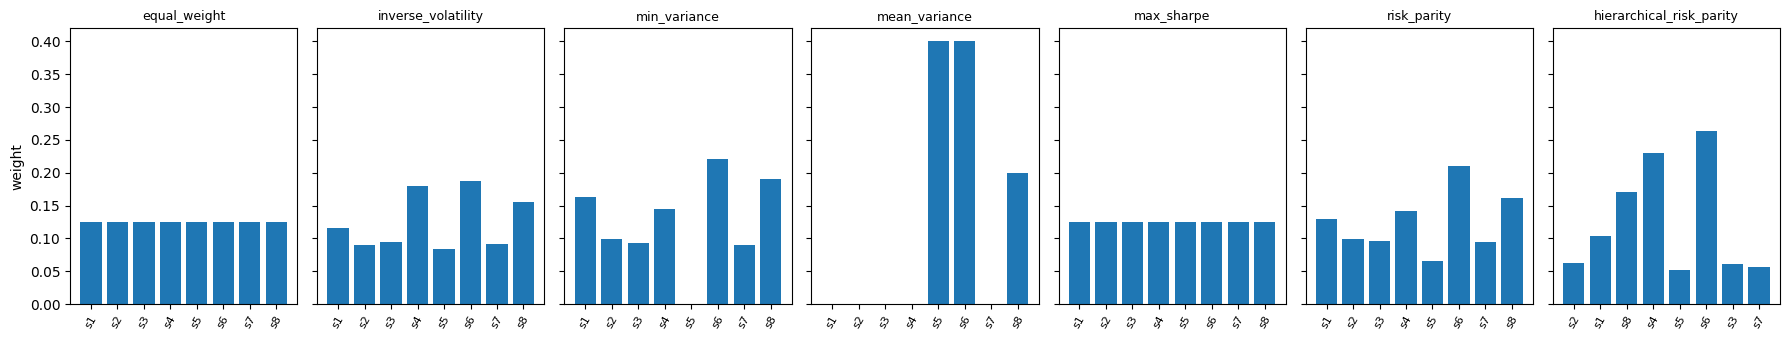

In [3]:
# Visualise the resulting weights side-by-side.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(methods), figsize=(18, 3.5), sharey=True)
for ax, m in zip(axes, methods):
    w = construct_portfolio(m, sids, cov=cov, expected_returns=mu, max_weight=0.4)
    ax.bar(list(w.keys()), list(w.values()))
    ax.set_title(m.value, fontsize=9)
    ax.tick_params(axis="x", rotation=60, labelsize=8)
    ax.axhline(0, color="black", linewidth=0.5)
axes[0].set_ylabel("weight")
plt.tight_layout()
plt.show()

## 2. Correlation cache (dirty-flag pattern)

The `StrategyDatabase` caches the pairwise correlation matrix and
only recomputes it when the underlying data changes.  We verify
that:

* repeated reads do **not** recompute,
* PM-status changes (live / flagged / retired) do **not** recompute,
* adding a new strategy and appending new bars **do** invalidate,
* and that the resulting speedup on a steady-state PM rebalance is
  large enough to matter at long-backtest scale.

In [4]:
# Display the correlation matrix.
corr = db.correlation_matrix
print(f"Correlation matrix is {corr.shape[0]}x{corr.shape[1]}; "
      f"dirty? {db.is_correlation_cache_dirty()}")
corr.round(2)

Correlation matrix is 9x9; dirty? False


,s1,s2,s3,s4,s5,s6,s7,s8,s_bad
s1,1.00,0.01,0.04,0.03,0.01,-0.01,0.06,0.01,-0.02
s2,0.01,1.00,0.06,0.06,0.06,-0.02,0.01,0.02,-0.03
s3,0.04,0.06,1.00,0.04,0.05,0.03,0.12,0.09,0.02
s4,0.03,0.06,0.04,1.00,0.90,0.03,0.04,0.11,-0.01
s5,0.01,0.06,0.05,0.90,1.00,0.01,0.07,0.11,-0.02
s6,-0.01,-0.02,0.03,0.03,0.01,1.00,0.10,0.05,0.04
s7,0.06,0.01,0.12,0.04,0.07,0.10,1.00,-0.01,0.01
s8,0.01,0.02,0.09,0.11,0.11,0.05,-0.01,1.00,0.02
s_bad,-0.02,-0.03,0.02,-0.01,-0.02,0.04,0.01,0.02,1.00


In [5]:
# Cache invariants — each line should match the comment.
import time

# Fresh read populates the cache once.
_ = db.correlation_matrix
n0 = db.cache_stats()["n_recomputes"]

# (a) 100 repeat reads must not recompute.
for _ in range(100):
    _ = db.correlation_matrix
    _ = db.covariance_matrix()
n_repeat = db.cache_stats()["n_recomputes"] - n0
print(f"(a) 100 repeat reads triggered {n_repeat} recompute(s)  [expect 0]")

# (b) PM-status changes must not invalidate.
db.set_pm_status("s2", PMStatus.LIVE)
db.flag_strategy("s3", "synthetic flag")
n_status = db.cache_stats()["n_recomputes"] - n0
print(f"(b) PM-status changes triggered {n_status} recompute(s)  [expect 0]")
assert not db.is_correlation_cache_dirty()

# (c) Adding a new strategy must dirty the cache.
extra = pd.Series(
    np.random.RandomState(1).normal(0.0005, 0.005, size=600),
    index=pd.date_range("2020-01-01", periods=600, freq="1min"),
    name="s_new",
)
new_rec = StrategyRecord(
    id="s_new", name="Strategy s_new",
    backtest_metrics=StrategyBacktestMetrics(
        annualised_return=0.4, annualised_volatility=0.10,
        sharpe_ratio=4.0, max_drawdown=-0.05, hit_rate=0.55,
    ),
)
db.register_strategy(new_rec, portfolio_returns=extra)
print(f"(c) register_strategy → dirty={db.is_correlation_cache_dirty()}  [expect True]")

# (d) Reading once triggers exactly one recompute, then it's clean again.
_ = db.correlation_matrix
print(f"(d) After read → dirty={db.is_correlation_cache_dirty()}  "
      f"recomputes={db.cache_stats()['n_recomputes']}  [expect False / +1]")

# (e) append_returns also dirties the cache.
db.append_returns(
    "s1",
    pd.Series([0.001, -0.001],
              index=pd.date_range("2020-01-02", periods=2, freq="1min"),
              name="s1"),
)
print(f"(e) append_returns → dirty={db.is_correlation_cache_dirty()}  [expect True]")
_ = db.correlation_matrix  # clear it

# (f) Timing: 50 PM-style accesses vs 50 forced refreshes on this DB.
t0 = time.perf_counter()
for _ in range(50):
    _ = db.correlation_matrix
    _ = db.covariance_matrix()
t_cached = time.perf_counter() - t0
t0 = time.perf_counter()
for _ in range(50):
    db.refresh_correlations()
t_forced = time.perf_counter() - t0
print(f"(f) cached reads: {t_cached*1000:6.2f} ms  |  "
      f"forced refreshes: {t_forced*1000:7.2f} ms  |  "
      f"speedup: {t_forced/max(t_cached,1e-9):.0f}x")

(a) 100 repeat reads triggered 0 recompute(s)  [expect 0]
(b) PM-status changes triggered 0 recompute(s)  [expect 0]
(c) register_strategy → dirty=True  [expect True]
(d) After read → dirty=False  recomputes=2  [expect False / +1]
(e) append_returns → dirty=True  [expect True]
(f) cached reads:   0.40 ms  |  forced refreshes:  557.90 ms  |  speedup: 1390x


## 3. PM Agent – SELECTOR mode

We rebuild a clean DB so the previous cells' mutations don't carry
over, then run the agent with the three pre-baked personalities.
Expected behaviour:

* `s_bad` (Sharpe = −0.5) must be filtered out by every personality.
* The highly-correlated pair `(s4, s5)` should not both appear in
  the defensive PM's book (it caps ρ at 0.70).
* `s1` started as LIVE with bad live metrics → the `monitor`
  node should flag it for review (rule-based path in SELECTOR mode).

In [6]:
# A *fresh* DB per personality so each PM sees s1 in its initial
# LIVE-with-bad-live-metrics state.  Otherwise the first PM flags s1
# and the subsequent ones no longer see it as LIVE (which is correct
# behaviour, but it would invalidate the per-personality assertion below).
results = {}
for personality in (PMPersonality.DEFENSIVE, PMPersonality.BALANCED, PMPersonality.AGGRESSIVE):
    db_local = build_synthetic_strategy_db()
    state = PortfolioManagerState(
        pm_name=f"{personality.value}_pm",
        mode=PMMode.SELECTOR,
        personality=personality,
        strategy_db=db_local,
        portfolio_db=PortfolioDatabase(),
    )
    out = portfolio_manager_graph.invoke(state)
    results[personality.value] = out["portfolio_record"]

for p, rec in results.items():
    print(f"\n— {p.upper()} ({rec.construction_method.value}) —")
    for a in rec.allocations:
        if a.enabled:
            print(f"  {a.strategy_id:<8s}  w = {a.weight:+.4f}")
    if rec.flagged_strategy_ids:
        print(f"  flagged → {rec.flagged_strategy_ids}")
    print(f"  expected vol  = {rec.expected_metrics.get('expected_volatility'):.6f}")

max_sharpe solver failed (Positive directional derivative for linesearch); falling back to equal weight.



— DEFENSIVE (min_variance) —
  s6        w = +0.2500
  s8        w = +0.2500
  s5        w = +0.2500
  s7        w = +0.2500
  expected vol  = 0.002776

— BALANCED (risk_parity) —
  s6        w = +0.2387
  s8        w = +0.1858
  s1        w = +0.1475
  s2        w = +0.1137
  s3        w = +0.1083
  s7        w = +0.1068
  s5        w = +0.0990
  flagged → ['s1']
  expected vol  = 0.002043

— AGGRESSIVE (max_sharpe) —
  s6        w = +0.1667
  s8        w = +0.1667
  s1        w = +0.1667
  s5        w = +0.1667
  s7        w = +0.1667
  s2        w = +0.1667
  flagged → ['s1']
  expected vol  = 0.002360


In [7]:
# Compare allocations across personalities in a tidy table.
all_ids = sorted({a.strategy_id for rec in results.values() for a in rec.allocations})
df_alloc = pd.DataFrame(
    {p: {a.strategy_id: a.weight for a in rec.allocations} for p, rec in results.items()},
    index=all_ids,
).fillna(0.0)
df_alloc.index.name = "strategy_id"
df_alloc.round(3)

,defensive,balanced,aggressive
strategy_id,,,
s1,0.00,0.148,0.167
s2,0.00,0.114,0.167
s3,0.00,0.108,0.000
s5,0.25,0.099,0.167
s6,0.25,0.239,0.167
s7,0.25,0.107,0.167
s8,0.25,0.186,0.167


In [8]:
# Sanity assertions on the PM's behaviour.
assert "s_bad" not in df_alloc.index or (df_alloc.loc["s_bad"] == 0).all(), \
    "s_bad should be filtered out by every personality"

# s1 (LIVE with bad live metrics) must trigger *some* action from
# every PM — either flag (mild drift) or retire (severe drift).
# Note: the defensive PM is strict enough that s1's live Sharpe
# (-0.35) falls below its kill floor (-0.2), so it retires rather
# than flags.  Balanced & aggressive only flag.
for p, rec in results.items():
    took_action = "s1" in rec.flagged_strategy_ids or "s1" in rec.retired_strategy_ids
    assert took_action, f"{p} took no action on the failing live strategy s1"

# Defensive PM's max pairwise correlation is 0.70.  The synthetic
# pair (s4, s5) has design correlation ~0.9.  They should not both
# be deployed by the defensive PM.
defensive_alloc = {a.strategy_id: a.weight for a in results["defensive"].allocations if a.enabled}
assert not ({"s4", "s5"} <= set(defensive_alloc)), \
    "Defensive PM picked both halves of the highly-correlated pair"
print("All SELECTOR-mode assertions passed.")
print(f"  Defensive  → retired={results['defensive'].retired_strategy_ids}, "
      f"flagged={results['defensive'].flagged_strategy_ids}")
print(f"  Balanced   → retired={results['balanced'].retired_strategy_ids}, "
      f"flagged={results['balanced'].flagged_strategy_ids}")
print(f"  Aggressive → retired={results['aggressive'].retired_strategy_ids}, "
      f"flagged={results['aggressive'].flagged_strategy_ids}")

All SELECTOR-mode assertions passed.
  Defensive  → retired=['s1'], flagged=[]
  Balanced   → retired=[], flagged=['s1']
  Aggressive → retired=[], flagged=['s1']


## 4. Side-by-side PMs sharing one DB

Two PMs (defensive + aggressive) run over the same strategy book.
Each writes its own `PortfolioRecord`s into the shared
`PortfolioDatabase`, distinguished by `pm_name`.  We also confirm
that the `pm_status` updates from one PM don't trample the other.

In [9]:
db = build_synthetic_strategy_db()
shared_pdb = PortfolioDatabase()

for personality in (PMPersonality.DEFENSIVE, PMPersonality.AGGRESSIVE):
    state = PortfolioManagerState(
        pm_name=f"{personality.value}_sleeve",
        mode=PMMode.SELECTOR,
        personality=personality,
        strategy_db=db,
        portfolio_db=shared_pdb,
    )
    portfolio_manager_graph.invoke(state)

print(f"Total portfolio records in DB: {len(shared_pdb.list_portfolios())}")
print()
for rec in shared_pdb.list_portfolios():
    weights = ", ".join(f"{a.strategy_id}={a.weight:.2f}"
                        for a in rec.allocations if a.enabled)
    print(f"  {rec.pm_name:>20s}  [{rec.construction_method.value:>25s}]  {weights}")

print()
print("Filter to one PM only:")
defensive_only = shared_pdb.list_portfolios(pm_name="defensive_sleeve")
print(f"  defensive_sleeve has {len(defensive_only)} record(s)")

max_sharpe solver failed (Positive directional derivative for linesearch); falling back to equal weight.


Total portfolio records in DB: 2

      defensive_sleeve  [             min_variance]  s6=0.25, s8=0.25, s5=0.25, s7=0.25
     aggressive_sleeve  [               max_sharpe]  s6=0.17, s8=0.17, s5=0.17, s7=0.17, s2=0.17, s3=0.17

Filter to one PM only:
  defensive_sleeve has 1 record(s)


## 5. PM Committee (multi-PM consensus)

When several PMs are active, instead of each running its own sleeve,
they can be aggregated into **one** consensus allocation via
`run_pm_committee`.  Each PM is invoked in `propose_only` mode (no DB
mutations), the committee aggregates their proposals using one of
three voting methods, and the consensus is the only thing that
actually mutates `strategy_db` / `portfolio_db`.

Key invariants verified below:

1. **Single-PM passthrough** — calling the committee with one PM is
   byte-for-byte identical to invoking that PM directly.
2. **Three-PM SIMPLE_AVERAGE** — produces a fully-invested consensus;
   strategies the committee flags / retires are excluded from the
   final allocations.
3. **propose-only correctness** — exactly one `PortfolioRecord` is
   persisted, and the DB `pm_status` only reflects the consensus, not
   any individual PM's view.
4. **WEIGHTED_AVERAGE chair** — explicit per-PM weights actually shift
   the consensus.

In [ ]:
from quant_fund_agent.agents.portfolio_manager.committee import (
    CommitteeConfig, run_pm_committee,
)
from quant_fund_agent.schemas import VotingMethod


def _make_pm(personality, sdb, pdb, name=None):
    return PortfolioManagerState(
        pm_name=name or f"pm_{personality.value}",
        mode=PMMode.SELECTOR,
        personality=personality,
        profile=get_personality_profile(personality),
        strategy_db=sdb,
        portfolio_db=pdb,
    )


# ── (1) Single-PM passthrough — must equal a direct invoke ─────────
sdb_d, pdb_d = build_synthetic_strategy_db(), PortfolioDatabase()
sdb_c, pdb_c = build_synthetic_strategy_db(), PortfolioDatabase()
direct = portfolio_manager_graph.invoke(
    _make_pm(PMPersonality.BALANCED, sdb_d, pdb_d, "x")
)["portfolio_record"]
via_committee = run_pm_committee(
    [_make_pm(PMPersonality.BALANCED, sdb_c, pdb_c, "x")],
    CommitteeConfig(),
    sdb_c, pdb_c,
)
w_direct = {a.strategy_id: a.weight for a in direct.allocations}
w_committee = {a.strategy_id: a.weight for a in via_committee.allocations}
assert w_direct == w_committee, "single-PM passthrough must equal direct invoke"
assert via_committee.pm_name == "x", "single-PM passthrough must keep pm_name"
print(f"(1) single-PM passthrough: {len(w_direct)} allocations, "
      f"identical to direct invoke ✓")

# ── (2) Three-PM SIMPLE_AVERAGE consensus ──────────────────────────
sdb, pdb = build_synthetic_strategy_db(), PortfolioDatabase()
pms = [_make_pm(p, sdb, pdb, p.value) for p in (
    PMPersonality.DEFENSIVE, PMPersonality.BALANCED, PMPersonality.AGGRESSIVE,
)]
rec_avg = run_pm_committee(pms, CommitteeConfig(pm_name="board"), sdb, pdb)
w_avg = {a.strategy_id: a.weight for a in rec_avg.allocations if a.enabled}
assert abs(sum(w_avg.values()) - 1.0) < 1e-6, "consensus weights must sum to 1"
assert not (set(rec_avg.flagged_strategy_ids) & set(w_avg)), \
    "a flagged strategy must NOT appear in the consensus weights"
assert not (set(rec_avg.retired_strategy_ids) & set(w_avg)), \
    "a retired strategy must NOT appear in the consensus weights"
print(f"(2) 3-PM SIMPLE_AVERAGE: {len(w_avg)} allocations, "
      f"flagged={rec_avg.flagged_strategy_ids}, "
      f"retired={rec_avg.retired_strategy_ids} ✓")
print("    consensus:  " + ", ".join(
    f"{k}={v:+.3f}" for k, v in sorted(w_avg.items(), key=lambda kv: -kv[1])
))

# ── (3) propose-only correctness — DB only mutated once ────────────
sdb, pdb = build_synthetic_strategy_db(), PortfolioDatabase()
pms = [_make_pm(p, sdb, pdb, p.value)
       for p in (PMPersonality.DEFENSIVE, PMPersonality.AGGRESSIVE)]
rec_po = run_pm_committee(pms, CommitteeConfig(pm_name="board2"), sdb, pdb)
live = {r.id for r in sdb.list_strategies() if r.pm_status.value == "live"}
expected = {a.strategy_id for a in rec_po.allocations if a.enabled}
assert live == expected, \
    f"DB LIVE set must equal consensus; diff={live ^ expected}"
assert len(pdb.list_portfolios()) == 1, \
    f"committee should persist exactly one record (got {len(pdb.list_portfolios())})"
print(f"(3) propose_only: DB LIVE == consensus, "
      f"PortfolioDatabase has exactly 1 record ✓")

# ── (4) WEIGHTED_AVERAGE chair effect ──────────────────────────────
sdb1, pdb1 = build_synthetic_strategy_db(), PortfolioDatabase()
sdb2, pdb2 = build_synthetic_strategy_db(), PortfolioDatabase()
r_agg_chair = run_pm_committee(
    [_make_pm(PMPersonality.DEFENSIVE, sdb1, pdb1, "def"),
     _make_pm(PMPersonality.AGGRESSIVE, sdb1, pdb1, "agg")],
    CommitteeConfig(
        voting_method=VotingMethod.WEIGHTED_AVERAGE,
        pm_weights={"def": 1.0, "agg": 5.0},
        pm_name="agg_chair",
    ),
    sdb1, pdb1,
)
r_def_chair = run_pm_committee(
    [_make_pm(PMPersonality.DEFENSIVE, sdb2, pdb2, "def"),
     _make_pm(PMPersonality.AGGRESSIVE, sdb2, pdb2, "agg")],
    CommitteeConfig(
        voting_method=VotingMethod.WEIGHTED_AVERAGE,
        pm_weights={"def": 5.0, "agg": 1.0},
        pm_name="def_chair",
    ),
    sdb2, pdb2,
)
w_agg = {a.strategy_id: a.weight for a in r_agg_chair.allocations if a.enabled}
w_def = {a.strategy_id: a.weight for a in r_def_chair.allocations if a.enabled}
shift = sum(abs(w_agg.get(k, 0) - w_def.get(k, 0))
            for k in set(w_agg) | set(w_def))
assert shift > 0.1, "chair weighting should materially shift the consensus"
print(f"(4) WEIGHTED_AVERAGE chair effect: total |Δw| = {shift:.3f} (>0.1) ✓")
print(f"    agg-chair top:  "
      + ", ".join(f"{k}={v:+.3f}" for k, v in
                  sorted(w_agg.items(), key=lambda kv: -kv[1])[:4]))
print(f"    def-chair top:  "
      + ", ".join(f"{k}={v:+.3f}" for k, v in
                  sorted(w_def.items(), key=lambda kv: -kv[1])[:4]))

In [ ]:
# Optional: LLM moderator path.  Same DB & PMs as (2), but instead of
# averaging we ask an LLM to read all three proposals (including their
# rationales) and synthesise the consensus.  Skipped if OPENAI_API_KEY
# isn't set.
from dotenv import load_dotenv
load_dotenv()

if not os.getenv("OPENAI_API_KEY"):
    print("OPENAI_API_KEY not set — skipping LLM moderator test.")
else:
    sdb, pdb = build_synthetic_strategy_db(), PortfolioDatabase()
    pms = [_make_pm(p, sdb, pdb, p.value) for p in (
        PMPersonality.DEFENSIVE, PMPersonality.BALANCED, PMPersonality.AGGRESSIVE,
    )]
    rec_llm = run_pm_committee(
        pms,
        CommitteeConfig(
            voting_method=VotingMethod.LLM_MODERATOR,
            pm_name="board_llm_moderator",
        ),
        sdb, pdb,
    )
    w_llm = {a.strategy_id: a.weight for a in rec_llm.allocations if a.enabled}
    assert abs(sum(w_llm.values()) - 1.0) < 1e-6
    assert not (set(rec_llm.flagged_strategy_ids) & set(w_llm))
    assert not (set(rec_llm.retired_strategy_ids) & set(w_llm))
    print(f"LLM-moderator consensus: {len(w_llm)} allocations, "
          f"flagged={rec_llm.flagged_strategy_ids}, "
          f"retired={rec_llm.retired_strategy_ids}")
    print("Top weights:  " + ", ".join(
        f"{k}={v:+.3f}" for k, v in sorted(w_llm.items(), key=lambda kv: -kv[1])[:6]
    ))
    print("\nModerator rationale:")
    print(rec_llm.pm_rationale)

## 6. Incremental simulation loop

Mimics what would happen inside the year-long backtest: each
"timestep" we (a) append a few new bars of PnL to every strategy
and (b) ask the PM to rebalance.  Confirms that the cache only
recomputes when bars are actually appended — `n_recomputes` should
equal the number of timesteps, not 2 × the number of timesteps
even though the PM reads both `correlation_matrix` and
`covariance_matrix` per call.

In [10]:
db = build_synthetic_strategy_db()
pdb = PortfolioDatabase()
rng = np.random.default_rng(123)

N_TIMESTEPS = 10
BARS_PER_STEP = 20
sids = [s.id for s in db.list_strategies() if s.id != "s_bad"]
last_idx = db.load_returns(sids[0]).index[-1]

recompute_history = []
for step in range(N_TIMESTEPS):
    # 1. New bars of PnL arrive for every strategy.
    new_idx = pd.date_range(last_idx + pd.Timedelta("1min"),
                            periods=BARS_PER_STEP, freq="1min")
    for sid in sids:
        new = pd.Series(rng.normal(0.0005, 0.005, size=BARS_PER_STEP),
                        index=new_idx, name=sid)
        db.append_returns(sid, new, persist_every_n=5)
    last_idx = new_idx[-1]

    # 2. PM rebalances.
    state = PortfolioManagerState(
        pm_name="sim_pm",
        mode=PMMode.SELECTOR,
        personality=PMPersonality.BALANCED,
        strategy_db=db,
        portfolio_db=pdb,
    )
    portfolio_manager_graph.invoke(state)
    recompute_history.append(db.cache_stats()["n_recomputes"])

print(f"Recomputes after each timestep: {recompute_history}")
print(f"Total PortfolioRecords written: {len(pdb.list_portfolios())}")
print(f"  ⇒ {N_TIMESTEPS} timesteps  →  {recompute_history[-1]} recomputes "
      f"(one per timestep, cache hit on the cov read).")
db.flush_returns()

Recomputes after each timestep: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Total PortfolioRecords written: 10
  ⇒ 10 timesteps  →  10 recomputes (one per timestep, cache hit on the cov read).


## 7. PM Agent – ACTIVE mode  *(requires `OPENAI_API_KEY`)*

In ACTIVE mode the LLM picks the construction method and may
override the rule-based screen / monitor.  This cell is skipped
gracefully when no API key is available.

In [11]:
from dotenv import load_dotenv
load_dotenv()

if not os.getenv("OPENAI_API_KEY"):
    print("OPENAI_API_KEY not set — skipping ACTIVE-mode test.")
else:
    db = build_synthetic_strategy_db()
    state = PortfolioManagerState(
        pm_name="active_pm",
        mode=PMMode.ACTIVE,
        personality=PMPersonality.BALANCED,
        strategy_db=db,
        portfolio_db=PortfolioDatabase(),
        target_n_strategies=5,
    )
    out = portfolio_manager_graph.invoke(state)
    rec = out["portfolio_record"]

    print(f"ACTIVE PM picked method: {rec.construction_method.value}")
    print()
    print("Allocations:")
    for a in rec.allocations:
        if a.enabled:
            print(f"  {a.strategy_id:<8s}  w = {a.weight:+.4f}")
    print()
    print("Monitor actions (LLM):")
    for action in rec.metadata.get("monitor_actions", []):
        print(f"  {action['strategy_id']:<8s}  {action['action']:<6s}  "
              f"— {action.get('reasoning', '')[:90]}")
    print()
    print("PM rationale:")
    print(rec.pm_rationale)

ACTIVE PM picked method: risk_parity

Allocations:
  s6        w = +0.2576
  s4        w = +0.2416
  s8        w = +0.2126
  s1        w = +0.1637
  s7        w = +0.1245

Monitor actions (LLM):
  s1        retire  — The live Sharpe of -0.35 is below the kill floor of -0.4, indicating poor performance. Add

PM rationale:
I selected strategies s1, s4, s6, s7, and s8 as they all meet the hard constraints of a minimum in-sample Sharpe of 0.6 and a maximum drawdown of -0.1. Additionally, the pairwise correlations among these strategies are well within the limit of 0.8, ensuring diversification. Each strategy also represents different trading ideas, with s1 and s6 being high Sharpe strategies, while s4, s7, and s8 provide additional diversity in terms of risk and return profiles. This selection balances performance and risk management effectively.

I chose the risk parity method because it ensures that each strategy contributes equally to the overall portfolio risk, which is particularly im